In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


## Image Dataset (training on full frames)

Inspect dataset:

### Prepare dataset for training an autoencoder

In [3]:
from dataset import ImageDataset
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = ImageDataset(TRAIN_PATH, train_transform)
val_dataset = ImageDataset(VALIDATION_PATH, val_transform)

In [4]:
batch = next(iter(train_dataset))
batch.shape

torch.Size([1, 3, 64, 64])

In [5]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [6]:
next(iter(val_loader)).shape

torch.Size([64, 1, 3, 64, 64])

### Define and train an autoencoder

In [7]:
# from models.autoencoder import ImageAutoencoder
# from models.encoder import ViTPatchEncoder
# from models.decoder import ViTPatchDecoder

# PATCH_SIZE = 4
# H, W = 64, 64

# EMBED_DIM = 512
# MLP_SIZE = EMBED_DIM * 4
# print(f"Patch size = {PATCH_SIZE}, Embed dim = {EMBED_DIM}, MLP size = {MLP_SIZE}")

# encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
#                           embed_dim=EMBED_DIM,
#                           max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
#                           attn_dim=512,
#                           num_heads=4,
#                           mlp_size=MLP_SIZE,
#                           num_tf_layers=4)

# decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
#                           H = 64,
#                           W = 64,
#                           embed_dim=EMBED_DIM,
#                           max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
#                           attn_dim=512,
#                           num_heads=4,
#                           mlp_size=MLP_SIZE,
#                           num_tf_layers=4)

# autoencoder_img = ImageAutoencoder(encoder, decoder)

In [11]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder
import torch

EXISTING_PATH = '24-09-2025_10-28'

checkpoint_enc = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/encoder.pth')
checkpoint_dec = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/decoder.pth')

PATCH_SIZE = 8
H, W = 64, 64

EMBED_DIM = 128
MLP_SIZE = EMBED_DIM * 4
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=4)
decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=4)

encoder.load_state_dict(checkpoint_enc['model_state_dict'])
decoder.load_state_dict(checkpoint_dec['model_state_dict'])
autoencoder_img = ImageAutoencoder(encoder, decoder)

# torch.save({
#         'model_state_dict': autoencoder_img.encoder.state_dict(),
#     }, 'experiments_released/22-09-2025_20-39_Patch_AE/checkpoints/encoder.pth')

# torch.save({
#         'model_state_dict': autoencoder_img.decoder.state_dict(),
#     }, 'experiments_released/22-09-2025_20-39_Patch_AE/checkpoints/decoder.pth')

In [9]:
t = next(iter(val_loader))
t.shape

torch.Size([64, 1, 3, 64, 64])

Image autoencoder training

In [14]:
import torch.nn.functional as F
from train import Trainer
from evaluate import evaluate_autoencoder

def save_model(model, optimizer, scheduler, stats, model_name, save_path):
    """ Saving model checkpoint """

    torch.save({
        'model_state_dict': model.encoder.state_dict()
    }, f"{save_path}/encoder.pth")
    torch.save({
        'model_state_dict': model.decoder.state_dict()
    }, f"{save_path}/decoder.pth")
    
    print("Saved models")
    
    return

optimizer = torch.optim.AdamW(autoencoder_img.parameters(), lr=1e-3)
trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Patch_AE", 
                  criterion=F.l1_loss, existing_path=EXISTING_PATH)
trainer.train(train_loader, val_loader, 11, eval_freq=2e3, init_step=36520)


Ep 10 Iter 38000: Loss=0.06969): : 36520it [02:08, ?it/s]/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


{'iter': 38000, 'epoch': 10, 'loss': 0.06968735158443451, 'MSE': 0.007037741897449373, 'MAE': 0.06483652410989112, 'SSIM': 0.5902728561112658, 'PSNR': 18.213065755503372, 'LPIPS': 0.2955575302441915, 'FVD': 7.8518445775906045}


Ep 10 Iter 40000: Loss=0.06669): : 36520it [04:35, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 76000, 'epoch': 20, 'loss': 0.06998063623905182, 'MSE': 0.0062278489398948375, 'MAE': 0.06150505125047045, 'SSIM': 0.6382721653738306, 'PSNR': 19.26982114534249, 'LPIPS': 0.2542707695563634, 'FVD': 6.3344892019725805}


Ep 20 Iter 76691: Loss=0.08203): : 36520it [45:50, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


Ep 20 Iter 76691: Loss=0.08203): : 36520it [46:07, ?it/s]

{'iter': 76691, 'epoch': 20, 'loss': 0.08202937990427017, 'mean_loss': np.float64(0.06812317493531816), 'MSE': 0.005596378364877657, 'MAE': 0.05786579863188115, 'SSIM': 0.7856545804528086, 'PSNR': 22.347914357494734, 'LPIPS': 0.1415463628768921, 'FVD': 2.518197348156896}
Training completed
Saved epoch_021_iter_76692's state to experiments/24-09-2025_10-28_Patch_AE/checkpoints/epoch_021_iter_76692.pth


In [ ]:
# torch.save({
#         'model_state_dict': autoencoder_img.state_dict(),
#     }, 'experiments_released/22-09-2025_19-24_Patch_AE/checkpoints/epoch_010_iter_36520.pth')

In [9]:
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder
import torch

checkpoint_encoder = torch.load('experiments_released/22-09-2025_20-39_Patch_AE/checkpoints/encoder.pth')
checkpoint_decoder = torch.load('experiments_released/22-09-2025_20-39_Patch_AE/checkpoints/decoder.pth')

PATCH_SIZE = 64
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=512,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=2048,
                          num_tf_layers=4)
decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=512,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=2048,
                          num_tf_layers=4)

encoder.load_state_dict(checkpoint_encoder['model_state_dict'])
decoder.load_state_dict(checkpoint_decoder['model_state_dict'])


<All keys matched successfully>

##### Inspect reconstruction of a random sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08124977..0.7274077].


torch.Size([1, 1, 3, 64, 64])


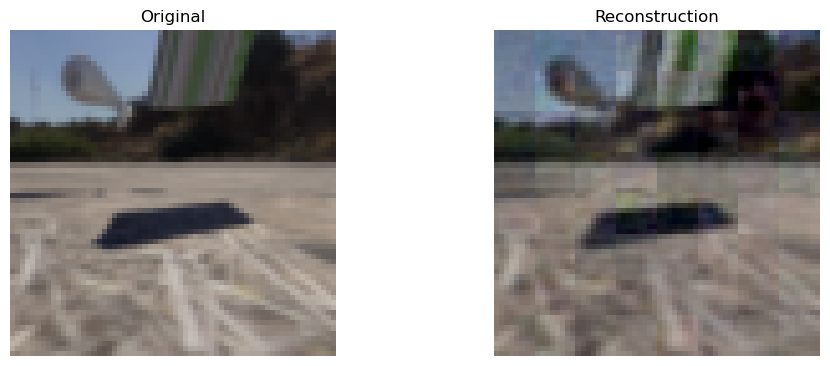

In [13]:
import matplotlib.pyplot as plt

sample = next(iter(val_dataset))
sample = sample.unsqueeze(0) # sample is of shape [B, C, H, W]
reconstr = autoencoder_img(sample.to(device))

print(reconstr.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample[0,0].permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstr[0,0].permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

## Mask Autoencoder

Prepare dataset

In [3]:
from dataset import MaskDataset
from torchvision import transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = MaskDataset(TRAIN_PATH, train_transform)
val_dataset = MaskDataset(VALIDATION_PATH, val_transform)

In [4]:
batch = next(iter(val_dataset))
batch[0].shape

torch.Size([1, 3, 64, 64])

In [5]:
B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE,
        shuffle=True,
        # num_workers=4,
        pin_memory=True
)
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        # num_workers=4
)

In [6]:
batch = next(iter(val_loader))
batch[0].shape # (batch size, 3, width, height)

torch.Size([64, 1, 3, 64, 64])

In [ ]:
import torch.nn.functional as F
from train import Trainer
from models.masked_object_transformer import MaskedObjectTransformer
from evaluate import evaluate_autoencoder

def save_models(model, optimizer, scheduler, stats, model_name, save_path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'stats': stats
    }, save_path)

DEFAULT_CRITERION = torch.nn.MSELoss()
def reconstruction_loss(ins, outs, mode='l1'):
    imgs, masks = ins
    
    if mode == 'l1':
        return F.l1_loss(outs, imgs)
    elif mode == 'mse':
        return F.mse_loss(outs, imgs)
    else:
        return DEFAULT_CRITERION(outs, imgs)

autoencoder_obj = MaskedObjectTransformer(obj_num=10, embed_dim=512,
                                          img_size=64, enc_depth=3,
                                          nhead=8, mlp_ratio=4.0)

optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=1e-4)
trainer = Trainer(model=autoencoder_obj, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Mask_AE", 
                  criterion=lambda outs, ins : reconstruction_loss(ins, outs, mode='l1'))
trainer.train(train_loader, val_loader, 10, eval_freq=3e3)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/user/kellerv1/object-repr-video-prediction/fvd.py:151: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


{'iter': 0, 'epoch': 0, 'loss': 0.1809418499469757, 'MSE': 0.045640916385232135, 'MAE': 0.1793223368994733, 'SSIM': 0.4045150472260458, 'PSNR': 14.374869792444768, 'LPIPS': 0.7491679039001465, 'FVD': 40.79299825168918}


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 3000, 'epoch': 0, 'loss': 0.05694463849067688, 'MSE': 0.006134944269433618, 'MAE': 0.05099130338652337, 'SSIM': 0.5842574332996654, 'PSNR': 22.727653648741093, 'LPIPS': 0.4767494576772054, 'FVD': 17.562821621584895}


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 6000, 'epoch': 1, 'loss': 0.042951058596372604, 'MSE': 0.004124267093658923, 'MAE': 0.04033683180967544, 'SSIM': 0.6488528431890533, 'PSNR': 24.466997039488813, 'LPIPS': 0.36898732201258344, 'FVD': 12.566600687689412}


...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 30000, 'epoch': 8, 'loss': 0.028161432594060898, 'MSE': 0.001958002798269166, 'MAE': 0.027057894347037408, 'SSIM': 0.7907028544015743, 'PSNR': 27.808923151950765, 'LPIPS': 0.21259643077850343, 'FVD': 7.5909643958689585}


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 33000, 'epoch': 9, 'loss': 0.028738941997289658, 'MSE': 0.0018689000243420138, 'MAE': 0.026452728527340482, 'SSIM': 0.8000805987409837, 'PSNR': 28.06827610691373, 'LPIPS': 0.2041840643088023, 'FVD': 7.31491157859891}


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 36000, 'epoch': 9, 'loss': 0.02560838684439659, 'MSE': 0.0017676444078964042, 'MAE': 0.025511203016689483, 'SSIM': 0.8067780733731468, 'PSNR': 28.32557415047517, 'LPIPS': 0.20098482163747153, 'FVD': 7.792013369571613}


Training completed


RuntimeError: File experiments/22-09-2025_11-45_Mask_AE/checkpoints cannot be opened.

In [14]:
torch.save({
        'model_state_dict': autoencoder_obj.state_dict(),
    }, 'experiments/22-09-2025_11-45_Mask_AE/checkpoints/model.pth')

Display results:

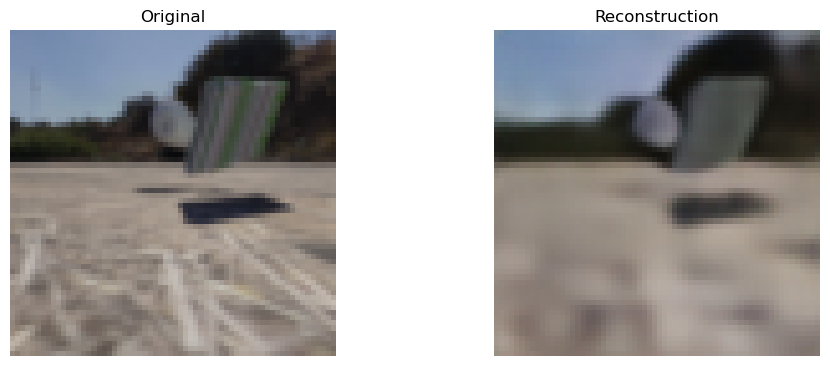

In [9]:
import matplotlib.pyplot as plt
batch = next(iter(val_loader))
sample = batch[0].to(device)
sample_masks = batch[1].to(device)

sample_out = autoencoder_obj((sample, sample_masks))
img_out = sample_out

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample[5][0].cpu().detach().permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_out[5][0].cpu().detach().squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

In [ ]:
# from save_load import load_model

# autoencoder_obj = MaskedObjectTransformer(obj_num=10, embed_dim=512,
#                                           img_size=64, enc_depth=3,
#                                           nhead=8, mlp_ratio=4.0)

# SAVE_PATH = 'experiments_released/21-09-2025_12-31_Mask_AE/checkpoints'
# optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=1e-4)
# load_model(autoencoder_obj, optimizer,
#             save_path=SAVE_PATH,
#             model_name='epoch_010')

# # optimizer is too heavy and not needed, save only model
# def save_models(model, optimizer, scheduler, stats, model_name, save_path):
#     torch.save({
#         'model_state_dict': model.state_dict(),
#         'stats': stats
#     }, f"{save_path}/{model_name}.pth")

# save_models(autoencoder_obj, optimizer, scheduler=None, stats={}, save_path=SAVE_PATH, model_name='epoch_010_iter_36520')